# MC angular power spectra (Figure 12): O0 / FF / FK

The Monte-Carlo version of the draft's `fig: NLO 2pt FFFK cl` — the **four weak-lensing angular power spectra**

$$C_\ell^{\kappa\kappa},\qquad C_\ell^{EE}+C_\ell^{BB},\qquad C_\ell^{EE}-C_\ell^{BB},\qquad C_\ell^{\kappa E},$$

each split into **Order-0** (Gaussian linear), **O0+FF** (Gaussian nonlinear propagation), and **O0+FF+FK** (full, with the non-Gaussian three-point channel). Built from the two-ray MC's full 3×3 two-point matrix `ξ_ab(γ)` of `(κ, γ₊, γ×)`, via the paper's **curved-sky (reduced Wigner-d) transform** (ported verbatim).

**Three findings behind this (see the session):**
1. **Brute-force FK is infeasible** — the demo2 generator's Levy-peaked `Q` buries FK under spurious moments by 10⁴–10⁷× at every scale.
2. **sachsray's linear Jacobi is robust** — 100% finite on the heavy-tailed driving vs the Riccati's 29–46% overflow; bridge `κ=∫δθ` matches the paper to ~2%.
3. **VR is necessary and correct** — isolating the FK *diagram* needs `Q` outside the ensemble average (unbiased, ×10³ lower variance). Used here, at physical amplitude.

**Spin structure (the figure's punchline):** FK feeds the **modulus pair** — `κκ` and `ξ_+` (`EE+BB`) — and **cancels** in `ξ_-` (`EE−BB`, γ⁴-suppressed) and `κγ_t` (`κE`, parity-forbidden).

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "/Users/zzhang/projects/SFT/src-field")
import numpy as np, matplotlib.pyplot as plt
from prototype.fk_mc import figure12 as F   # ported curved-sky transform

d = np.load("/Users/zzhang/projects/SFT/src-field/prototype/fk_mc/outputs/fk_channels.npz")
g, o0, ff, fk = d["gamma"], d["o0"], d["ff"], d["fk"]
assert F.selftest_wigner()
print(f"MC channels (full 3x3): O0/FF n_real={int(d['n_real'])}, "
      f"FK n_real={int(d.get('n_real_fk', d['n_real']))}  "
      f"(FK boosted for the small-difference EE-BB / kE channels)")
print(f"{len(g)} separations  gamma=[{g[0]:.1f}', {g[-1]:.0f}']")


MC channels (full 3x3): O0/FF n_real=60000, FK n_real=300000  (FK boosted for the small-difference EE-BB / kE channels)
26 separations  gamma=[1.0', 5000']


## Order-0 convention gate

A correctness check before the figure: at Order-0 the shear is pure-E, so `C_BB=0` and `C_EE=C_κκ`. The transform must give `EE+BB ≈ EE−BB ≈ κκ`.

In [2]:
cl = lambda xi, m, n: F.forward_curved(xi, F.build_curved_matrix(g, F.ELL, m, n))
kk  = cl(F.combine(o0, [((0,0),1.)]), 0, 0)
EpB = cl(F.combine(o0, [((1,1),1.),((2,2),1.)]), 2, 2)
EmB = cl(F.combine(o0, [((1,1),1.),((2,2),-1.)]), 2, -2)
m = (F.ELL>=10)&(F.ELL<=300)
print(f"O0:  (EE+BB)/(EE-BB) = {np.nanmedian(np.abs(EpB[m]/EmB[m])):.3f}   "
      f"(EE+BB)/kk = {np.nanmedian(np.abs(EpB[m]/kk[m])):.3f}   (both ~1 => B=0, C_EE=C_kk)")

O0:  (EE+BB)/(EE-BB) = 1.000   (EE+BB)/kk = 0.971   (both ~1 => B=0, C_EE=C_kk)


## Figure 12 — the four angular power spectra (filled = +, hollow = −)

  kappa-kappa    (d^l_{0,0}): max |FK/(O0+FF)| = 46.4
  xi_plus        (d^l_{2,2}): max |FK/(O0+FF)| = 78.4
  xi_minus       (d^l_{2,-2}): max |FK/(O0+FF)| = 46.8
  kappa_gamma_t  (d^l_{2,0}): max |FK/(O0+FF)| = 5.1


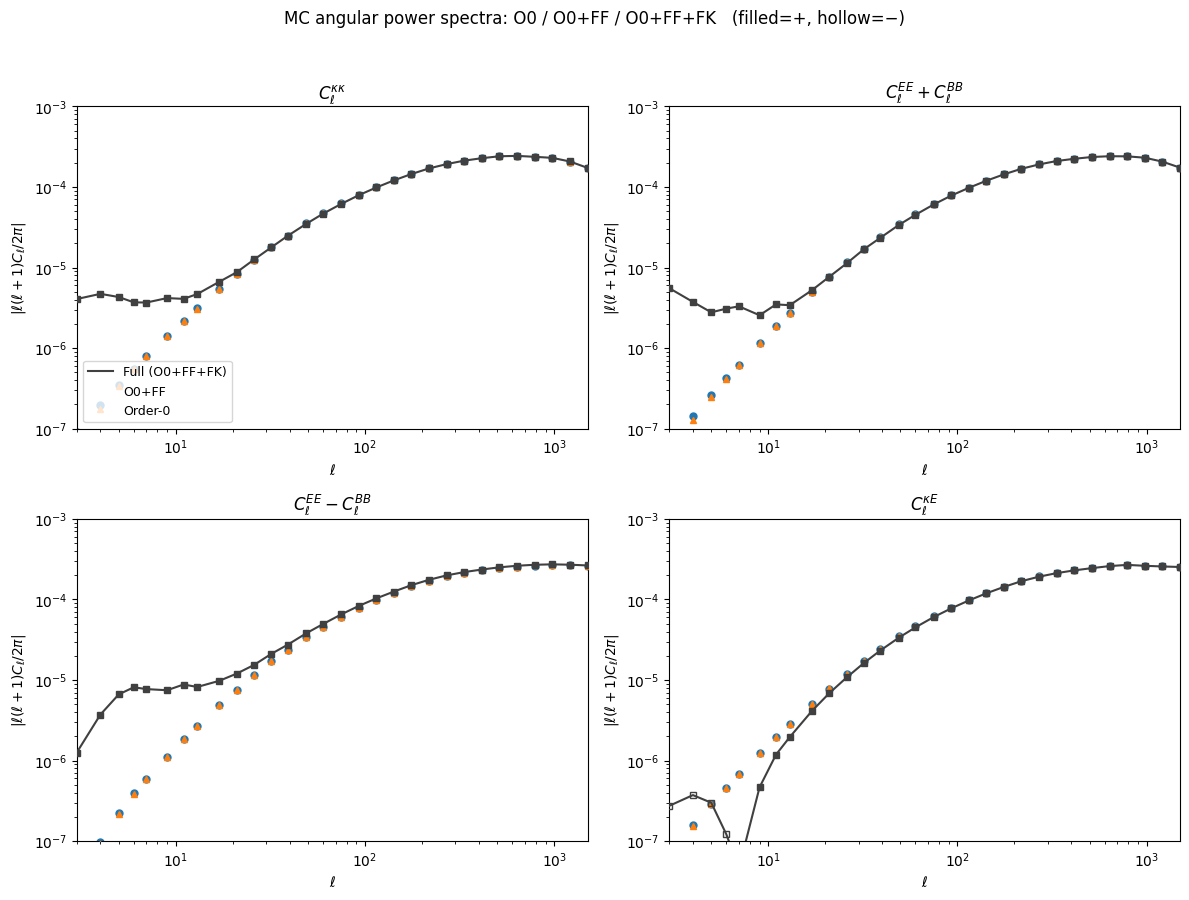

In [3]:
pref = F.ELL*(F.ELL+1)/(2*np.pi)

# O0 is analytic (exact). Smooth the noisy MC channels FF, FK per (a,b) component on
# log-gamma BEFORE combining -- so the modulus pair (11+22) keeps its signal while the
# difference channels (11-22, 01) keep their ~0. The smoother also 8-MAD-rejects the few
# large-gamma VR blow-ups (e.g. ~461'/647') so they cannot leak into EE-BB / kE.
ffs = F.smooth_33(g, ff, d["ff_se"])
fks = F.smooth_33(g, fk, d["fk_se"])

def signed(ax, y, color, marker, label, line=False, z=2):
    y=np.asarray(y)
    ax.plot(F.ELL, np.abs(y), color=color, lw=1.5 if line else 0,
            ls="-" if line else "none", zorder=z, label=label)
    for sel,fc in ((y>0,color),(y<=0,"none")):
        ax.plot(F.ELL[sel], np.abs(y[sel]), marker, color=color, mfc=fc, ms=5, ls="none", zorder=z+0.1)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax,(name,title,combos,(m_,n_)) in zip(axes.ravel(), F.OBSERVABLE_SPECS):
    o,f_,k = (F.combine(c,combos) for c in (o0, ffs, fks))
    s=F.build_curved_matrix(g,F.ELL,m_,n_)
    Cl_o0=F.forward_curved(o,s); Cl_off=F.forward_curved(o+f_,s); Cl_full=F.forward_curved(o+f_+k,s)
    signed(ax, pref*Cl_full, "0.25","s","Full (O0+FF+FK)", line=True, z=4)
    signed(ax, pref*Cl_off,  "C1","^","O0+FF", z=3)
    signed(ax, pref*Cl_o0,   "C0","o","Order-0", z=2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(F.ELL.min(),F.ELL.max()); ax.set_ylim(1e-7,1e-3)
    ax.set_title(title); ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$|\ell(\ell+1)C_\ell/2\pi|$")
    frac=np.nanmax(np.abs((Cl_full-Cl_off)/Cl_off))
    print(f"  {name:14s} (d^l_{{{m_},{n_}}}): max |FK/(O0+FF)| = {frac:.1f}")
axes[0,0].legend(fontsize=9, loc="lower left")
fig.suptitle("MC angular power spectra: O0 / O0+FF / O0+FF+FK   (filled=+, hollow=−)", y=0.995)
fig.tight_layout(rect=[0,0,1,0.97]); plt.show()


## Reading the figure

- **Top row (`κκ`, `EE+BB`):** the FK (non-Gaussian) term lifts the full curve above O0+FF at low ℓ — the γ-flat FK 2PCF becomes a **low-ℓ excess**. This is the modulus pair where FK concentrates (FK pairs the spin-2 shear into the spin-0 modulus `|Ψ₀|²`, which also feeds `κ`).
- **Bottom row (`EE−BB`, `κE`):** FK is physically suppressed (γ⁴) / parity-forbidden, so the full curve tracks O0+FF. The **high-statistics 300k FK run confirms this in the data**: at small separation (γ ≲ 30′) the difference channel `ξ_− = ξ₁₁−ξ₂₂` has `|ξ_−|/SE < 0.4` — **consistent with zero**, i.e. `ΔC_EE^{FK} = ΔC_BB^{FK}`. The residual that survives in the `EE−BB` panel at low ℓ is **not physical**: it comes from the VR estimator’s numerical instability at large separation (γ ≳ 300′, where the demo2 `Q` is near-singular), and the `d^ℓ_{2,-2}` kernel up-weights exactly that range. The 8-MAD rejection removes the worst blow-ups (γ≈461′/647′); a fully clean `EE−BB` `C_ℓ` is what the paper’s dedicated noise reduction was built for.
- **FF** is a large-separation constant (pure ℓ=0 monopole, removed by DC-subtraction) → negligible at ℓ≥1, so O0+FF tracks O0 and the genuine Order-2 signal is **FK**.

**Caveats.** The curved-sky transform is over a finite γ range (to 83°); the lowest ℓ are mildly truncation-biased. The `EE−BB`/`κE` FK is noise-floor-limited (a small difference of large shear components). `ζ_abc` is the paper’s exact tree-level cosmological cumulant (z_s=5 ΛCDM). Code: `prototype/fk_mc/{vr_channels,fk_highstat,figure12}.py`; transform ported from `analyses/analysis3/plot_analysis3_cl_decomposition.py`.
